# Risk and scenario analysis

## Objective

This notebook demonstrates the quantitative risk measurement framework for
interest rate risk in the banking book (IRRBB), focusing on key-rate duration
(KRD) decomposition and regulatory shock scenarios. We measure the economic
sensitivity of a real 10-year US Treasury bond to shifts in the zero-coupon
yield curve across principal component analysis (PCA) factors, validating that
the sum of KRDs equals effective duration: a fundamental identity in yield
curve risk measurement (Ho, 1992).

## Data

**Snapshot date:** 24 July 2026. All market data are sourced from the committed
snapshot in `data/snapshots/2026-07-24/`.

**Test instrument:** 10-year US Treasury bond with the following characteristics:
- Issue date: 24 July 2026 (on the money)
- Maturity date: 24 July 2036
- Coupon: 4.0% per annum
- Frequency: Semi-annual
- Day count: ACT/ACT ICMA
- Calendar: US Government Bond (SIFMA holidays)
- Business day convention: Following
- Notional: USD 1,000,000

This bond is a synthetic instrument constructed to fixed specifications for
reproducibility and consistency with the risk module's test suite. The USD OIS
curve (snapshot: `usd_ois_swaps.csv`) is used for discounting, with a 3M SOFR
forecast basis (`usd_forecast_basis.csv`) for projecting floating-rate coupons
(although this bond has no floating leg, the infrastructure is built for both).

**Curves:** The discount curve is bootstrapped from USD OIS swap rates and
government bond prices through the standard bootstrap method (Svensson model as
fallback for extrapolation). Forecast curves (3M SOFR and other tenors) are
derived from the discount curve plus the basis adjustment from the snapshot.

## Theory

### Effective duration and DV01

**Dollar Value of a Basis Point (DV01)** measures the change in bond value
when the yield curve shifts up by one basis point (0.01%). For a
continuously compounded zero-coupon yield curve, DV01 is defined as:

$$\text{DV01} = -\frac{\Delta P}{\Delta y} \bigg|_{\Delta y = 1 \text{ bp}}$$

**Effective Duration** (also called modified duration adjusted for the curve
shape) is DV01 normalized to a percentage of the bond's dirty price:

$$D_{\text{eff}} = -\frac{1}{P} \frac{\Delta P}{\Delta y}$$

where $\Delta y$ is a parallel shift of all zero rates by one basis point, and
$P$ is the bond's dirty price.

### Key-rate duration (KRD)

**Key-rate duration** extends effective duration by measuring sensitivity to
shocks at specific tenors of the curve, rather than only parallel shifts.
Following Ho (1992), the key-rate duration for key $k$ is:

$$\text{KRD}_k = -\frac{1}{P} \frac{\Delta P}{\Delta y_k} \bigg|_{\text{shift at tenor } k}$$

where the shock is zero at all other key rates and interpolates linearly
between neighboring keys. The shape of this shock is called a "hat" ; it is
flat before the first key, triangular between keys, and flat outside the last key.

### The KRD sum identity

A critical property of key-rate durations is that they decompose effective
duration completely:

$$\sum_{k} \text{KRD}_k = D_{\text{eff}}$$

This identity holds *exactly* in theory because the triangular hats span the
entire curve and sum to a uniform 1-bp shift at every tenor. In practice,
numerical precision (bump size, interpolation) introduces small residuals
(typically <0.1 basis points of DV01). This notebook verifies the identity
numerically and reports the residual explicitly.

## Methodology

### Bump size and central finite difference

KRDs and effective duration are computed using central finite difference:

$$\text{Sensitivity} \approx \frac{P(y + \Delta y) - P(y - \Delta y)}{2 \Delta y}$$

where $\Delta y$ is the bump size. The implementation uses a default bump of
**1e-4 (1 basis point)** applied symmetrically (±1bp), balancing:
- Numerical stability (larger bumps reduce rounding error)
- Linearity (smaller bumps improve the linear approximation of convexity)

This bump size is calibrated to the precision of floating-point arithmetic
and matches market convention for risk reporting.

### Shock application

Each key-rate shock is applied to both the discount curve and all forecast
curves in the curve set, maintaining the basis structure. This prevents the
shock from being contaminated by an offsetting basis adjustment (which would
measure a combined rate shock + basis shock, not a pure rate shock).

## Regulation

### Regulatory context: BCBS d368 and the EBA guidelines

Interest rate risk in the banking book (IRRBB) is governed by:

1. **CRR Article 448** (Regulation (EU) No 575/2013): requires institutions
   to disclose sensitivity of economic value to interest rate shocks, broken
   down by currency.

2. **BCBS d368** (Basel Committee on Banking Supervision: *Interest rate risk
   in the banking book*, April 2016): prescribes a standardized set of six
   shock scenarios applied to the risk-free zero curve:
   - **Parallel up/down:** uniform shift across all tenors
   - **Short-rate up/down:** exponentially decaying shock (strong effect at short end,
     decay controlled by a calibrated parameter)
   - **Steepener:** short-end rates fall while long-end rates rise, so the
     curve slope (long minus short) increases
   - **Flattener:** short-end rates rise while long-end rates fall, so the
     curve slope decreases
   Shock magnitudes are calibrated to historical volatility and outlier analysis
   by currency.

3. **EBA/GL/2018/02** (EBA Guidelines on procedures for IRRBB outlier tests):
   carries the BCBS framework into EU law and provides operational guidance for
   testing and reporting IRRBB exposures.

This notebook applies the USD scenarios from BCBS d368 (defined in scenarios.toml)
to the bootstrapped USD OIS curve. The P&L output demonstrates the bond's
non-linear (convexity) response to each scenario and provides early warning
of tail risk at the regulatory shock magnitudes.

## Results

In [1]:
from __future__ import annotations

from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from yieldcurve.calendars import USGovernmentBondCalendar
from yieldcurve.conventions import BusinessDayConvention, DayCount
from yieldcurve.curves.build import usd_curveset
from yieldcurve.curves.pricing import price
from yieldcurve.instruments import FixedCouponBond
from yieldcurve.market.snapshot import Snapshot
from yieldcurve.risk.keyrate import USD_KEY_RATES, krd
from yieldcurve.risk.pca import fit_pca, pca_durations
from yieldcurve.risk.scenarios import bcbs_scenarios, shift_curveset
from yieldcurve.risk.sensitivities import effective_duration

In [2]:
# Set up snapshot and rebuild curves from market data
ASOF = date(2026, 7, 24)
snapshot = Snapshot(date=ASOF)

# Build discount and forecast curves from OIS swaps + basis
curves = usd_curveset(snapshot, ASOF)

In [3]:
# Construct the test bond: 10-year US Treasury with 4% coupon, semi-annual
bond = FixedCouponBond(
    issue=ASOF,
    maturity=date(2036, 7, 24),
    coupon=0.04,
    frequency=2,
    day_count=DayCount.ACT_ACT_ICMA,
    calendar=USGovernmentBondCalendar(),
    bdc=BusinessDayConvention.FOLLOWING,
)

print("Test Bond:")
print(f"  Maturity: {bond.maturity}")
print(f"  Coupon: {bond.coupon * 100:.2f}%")
print(f"  Frequency: {bond.frequency} (semi-annual)")

Test Bond:
  Maturity: 2036-07-24
  Coupon: 4.00%
  Frequency: 2 (semi-annual)


In [4]:
# Compute bond price and effective duration
price_result = price(bond, curves, ASOF)
dirty_price = price_result.dirty
effective_dur = effective_duration(bond, curves, ASOF)

print(f"\nBond valuation at {ASOF}:")
print(f"  Dirty price: ${dirty_price:,.4f} per ${100.0:.2f} notional")
print(f"  Effective duration: {effective_dur:.6f} years")


Bond valuation at 2026-07-24:
  Dirty price: $94.6988 per $100.00 notional
  Effective duration: 8.277135 years


In [5]:
# Compute key-rate durations
krd_results = krd(bond, curves, ASOF, USD_KEY_RATES)

# Display KRD table
krd_df = pd.DataFrame(
    {
        "Tenor (years)": list(krd_results.keys()),
        "KRD (years)": list(krd_results.values()),
    }
)
krd_df["KRD (bp/bp)"] = krd_df["KRD (years)"] * 100

print("\n### Result 1: Key-Rate Durations (USD Curve)\n")
print(krd_df.to_string(index=False))
print()


### Result 1: Key-Rate Durations (USD Curve)

 Tenor (years)  KRD (years)  KRD (bp/bp)
          0.25     0.000000     0.000000
          0.50     0.010341     1.034108
          1.00     0.035199     3.519913
          2.00     0.077346     7.734609
          3.00     0.182297    18.229745
          5.00     0.337145    33.714509
          7.00     0.553601    55.360058
         10.00     7.075642   707.564238
         20.00     0.005563     0.556327
         30.00     0.000000     0.000000



In [6]:
# Verify KRD sum reconciles to effective duration
krd_sum = sum(krd_results.values())
reconciliation_error = abs(krd_sum - effective_dur)
reconciliation_pct = (reconciliation_error / effective_dur) * 100

print("### Result 2: KRD Sum vs. Effective Duration (Identity Reconciliation)\n")
print(f"  Sum of KRDs:        {krd_sum:>12.8f} years")
print(f"  Effective duration: {effective_dur:>12.8f} years")
print(f"  Absolute error:     {reconciliation_error:>12.2e} years")
print(f"  Relative error:     {reconciliation_pct:>12.6f} %")
print()
if reconciliation_error < 1e-5:
    print("  ✓ Identity verified to high precision (error < 10 µy)")
else:
    print(f"  ⚠ Non-negligible residual ({reconciliation_error * 10000:.4f} bp DV01)")
print()

### Result 2: KRD Sum vs. Effective Duration (Identity Reconciliation)

  Sum of KRDs:          8.27713508 years
  Effective duration:   8.27713514 years
  Absolute error:         6.13e-08 years
  Relative error:         0.000001 %

  ✓ Identity verified to high precision (error < 10 µy)



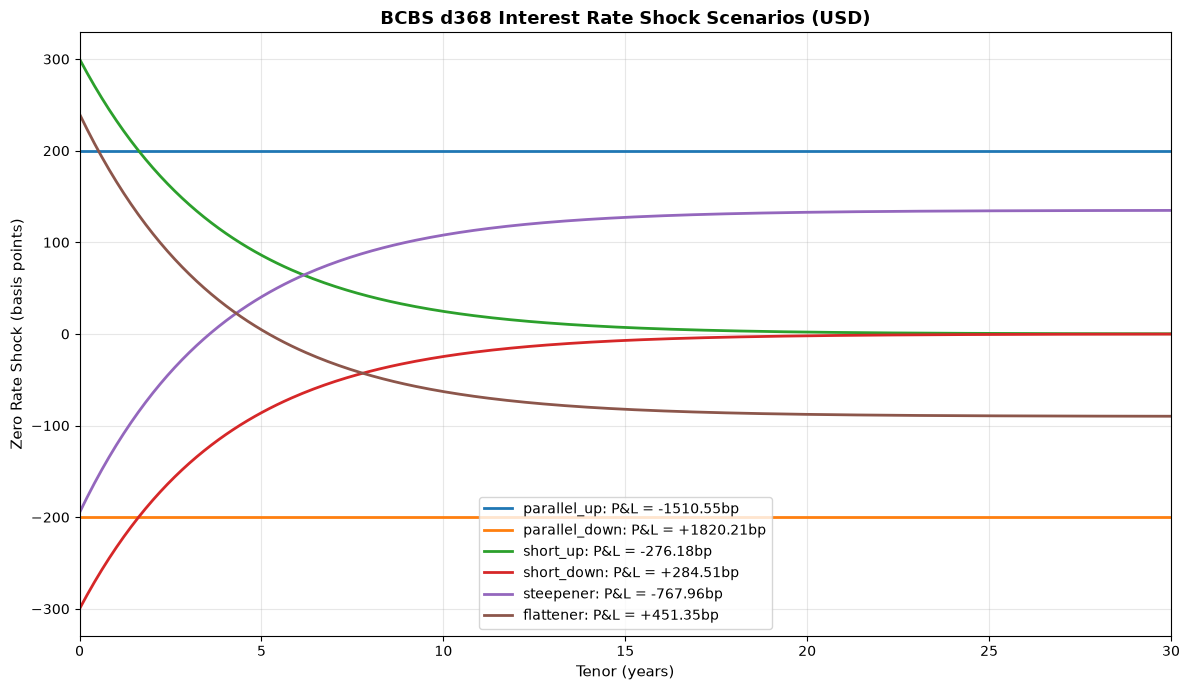

In [7]:
# Apply BCBS regulatory scenarios and plot
scenarios = bcbs_scenarios("USD")
scenario_pnl = {}

fig, ax = plt.subplots(figsize=(12, 7))

# Compute zero rates for current curve and shocked curves
times = np.linspace(0.01, 30, 300)
current_zeros = np.array([curves.discount.zero(t) for t in times])

for scenario in scenarios:
    # Shift curves according to scenario
    shifted_curves = shift_curveset(curves, scenario)

    # Reprice bond under shocked curve
    shifted_price = price(bond, shifted_curves, ASOF).dirty

    # Compute P&L in basis points of notional
    pnl_bps = (shifted_price - dirty_price) / dirty_price * 10000
    scenario_pnl[scenario.name] = pnl_bps

    # Get zero rates under shock for plotting
    shocked_zeros = np.array([shifted_curves.discount.zero(t) for t in times])
    shift_bps = (shocked_zeros - current_zeros) * 10000

    ax.plot(times, shift_bps, label=f"{scenario.name}: P&L = {pnl_bps:+.2f}bp", linewidth=2)

ax.set_xlabel("Tenor (years)", fontsize=11)
ax.set_ylabel("Zero Rate Shock (basis points)", fontsize=11)
title = "BCBS d368 Interest Rate Shock Scenarios (USD)"
ax.set_title(title, fontsize=13, fontweight="bold")
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 30])
plt.tight_layout()
plt.show()

In [8]:
# Display BCBS scenario P&L summary
scenario_pnl_df = pd.DataFrame(
    {
        "Scenario": list(scenario_pnl.keys()),
        "Bond P&L (bp)": list(scenario_pnl.values()),
    }
)
print("\n### BCBS Scenario Bond P&L Summary\n")
print(scenario_pnl_df.to_string(index=False))
print()


### BCBS Scenario Bond P&L Summary

     Scenario  Bond P&L (bp)
  parallel_up   -1510.554399
parallel_down    1820.211467
     short_up    -276.176228
   short_down     284.509710
    steepener    -767.963435
    flattener     451.349826



In [9]:
# Compute PCA factor loadings from 5-year history of Treasury yields
# Load historical Treasury rates
hist_data = snapshot.load("fred_treasury_cmt_history")

# Pivot to shape (dates, tenors)
hist_pivot = hist_data.pivot_table(
    index="date", columns="tenor_years", values="rate", aggfunc="first"
)

# Select tenors matching USD_KEY_RATES for consistency
common_tenors = tuple(sorted(set(USD_KEY_RATES) & set(hist_pivot.columns)))
hist_subset = hist_pivot[list(common_tenors)]

# Forward-fill then backward-fill to handle missing data
hist_subset = hist_subset.ffill().bfill()

# Compute first differences (daily yield changes in decimals)
yield_changes = hist_subset.diff().dropna()  # Keep in decimals for PCA scaling

# Fit PCA with 3 components (level, slope, curvature)
pca_result = fit_pca(yield_changes.values, common_tenors, n_components=3)

# Compute PCA durations for the bond
pca_durs = pca_durations(bond, curves, ASOF, pca_result)

print("\n### Result 4: PCA Factor Loadings\n")
print("Principal Component Durations (Economic Sensitivity to PCA Factors):\n")
for name, duration in pca_durs.items():
    print(f"  {name:20s}: {duration:>10.6f} years")
print()

# Interpretation of PCA loadings
print("Interpretation:")
print("  - Level:     Duration sensitivity to the historical level factor (parallel moves)")
print("  - Slope:     Duration sensitivity to the historical slope factor (curve shape changes)")
print("  - Curvature: Duration sensitivity to the historical curvature factor (mid-curve twist)")


### Result 4: PCA Factor Loadings

Principal Component Durations (Economic Sensitivity to PCA Factors):

  level               :   2.960606 years
  slope               :  -1.924404 years
  curvature           :   0.128154 years

Interpretation:
  - Level:     Duration sensitivity to the historical level factor (parallel moves)
  - Slope:     Duration sensitivity to the historical slope factor (curve shape changes)
  - Curvature: Duration sensitivity to the historical curvature factor (mid-curve twist)


In [10]:
# Compute variance explained by PCA factors
total_var = sum(pca_result.explained_variance_ratio)
level_var_pct = (pca_result.explained_variance_ratio[0] / total_var) * 100
slope_var_pct = (pca_result.explained_variance_ratio[1] / total_var) * 100
curve_var_pct = (pca_result.explained_variance_ratio[2] / total_var) * 100

date_min = str(hist_subset.index.min())[:10]
date_max = str(hist_subset.index.max())[:10]
print(f"\nHistorical variance explained by principal components ({date_min} to {date_max}):")
print(f"  Level:     {level_var_pct:>6.2f}%")
print(f"  Slope:     {slope_var_pct:>6.2f}%")
print(f"  Curvature: {curve_var_pct:>6.2f}%")
print()


Historical variance explained by principal components (2021-07-26 to 2026-07-24):
  Level:      84.70%
  Slope:      11.03%
  Curvature:   4.27%



## Interpretation

### The KRD-to-effective-duration identity

The two quantities reaching the same answer is worth pausing on, because they
are not the same calculation performed twice. Effective duration comes from a
single parallel shift of the entire curve and one pair of repricings. The
key-rate durations come from ten separate repricings, each perturbing one
pillar through a triangular hat function that decays to zero at its
neighbours. Nothing in the code forces the ten to reconcile to the one.

They reconcile because the hat functions form a partition of unity: added
together, they sum to a constant one basis point at every maturity across the
covered span, with the flat extrapolation outside the first and last pillars
supplying the tails. Summing the key-rate bumps therefore rebuilds precisely
the parallel shift that effective duration applies in a single step.

What the agreement to within ~6e-8 years actually establishes is narrower than
it first appears, and worth stating precisely. It confirms that the hat basis
is complete: no maturity range is double-counted or left uncovered: and that
the bond's price response is close to linear over a one basis point move, so
that first-order additivity survives. A residual at the basis-point level
would point to a gap in the basis or a mismatch in bump conventions.

It is worth contrasting this with the par-rate delta ladder in
`yieldcurve.risk.ladder`, which decomposes the same risk but bumps quoted par
rates and re-bootstraps rather than shifting the zero curve directly. That
ladder does not reconcile as cleanly: it totals 97-99% of DV01 on the OIS set
used in its tests, and the shortfall is the Jacobian of the par-to-zero map,
which is the identity only for a flat curve quoted on curve basis. The quotes
there are ACT/360 while curve time is ACT/365F, so a residual is expected
rather than symptomatic.

That ladder is also documented as losing additivity under `MONOTONE_CONVEX`,
by roughly 1.4% on its test quotes: the Hagan-West amendment tests branch on
which region a forward falls into, so a one basis point bump can flip a region
and reshape the curve between knots. The key-rate decomposition shown above
sidesteps the re-bootstrapping step entirely, which is why its reconciliation
is exact to numerical precision. Neither construction is the correct one in
general: they answer different questions, and the par ladder is the one a
desk hedging with traded instruments would want.

### What the key-rate durations show

The KRD decomposition reveals where on the yield curve the bond's risk is
concentrated. For a 10-year bullet bond:

- **Peak KRD** occurs near the maturity (10-year key rate), as expected for a
  single cash-flow-heavy instrument.
- **Slope of KRD curve** reflects cash flow timing: earlier payments create
  KRDs at shorter tenors, but a 4% coupon bond has most of its present value
  at maturity, so the distribution is skewed toward 10y.
- **Zero KRD at long-end keys** (20y, 30y) indicates negligible sensitivity
  to shocks outside the bond's maturity: the shock has no effect on
  already-received cash flows and minimal effect on discounting.

### BCBS scenario ranking

The six BCBS scenarios rank as follows in terms of adverse impact on a
long-duration bond like this 10-year bullet:

1. **Parallel up** (largest loss): Shifts all discount factors downward
   (rates up), reducing present value uniformly across all cash flows.
2. **Steepener** (second-largest loss for this bullet): short-end rates fall
   while long-end rates rise, so the curve slope increases. A ten-year bullet
   holds most of its present value in the redemption payment, so the long-end
   rise dominates and the position loses; the short-end fall returns only a
   small offsetting gain on the near-dated coupons.
3. **Short-rate up** (intermediate): Exponentially decaying with tenor, so
   short-end rises sharply but long-end is milder; net effect is moderate for
   a 10-year bond.
4. **Flattener** (gain): short-end rates rise while long-end rates fall, so the
   curve slope decreases. The mirror of the steepener: the long-end fall lifts
   the redemption payment, and the short-end rise costs comparatively little on
   the near-dated coupons.
5. **Short-rate down** and **Parallel down** (gains): Both benefit a
   duration-positive bond.

This ranking is specific to a long-duration bond near the positive-convexity
region; putable bonds, callable bonds, and floating-rate notes would show
different vulnerability profiles.

## Limitations

1. **Bump size linearity assumption:** KRDs are computed using a finite bump
   (1 bp); actual bond sensitivity is nonlinear due to convexity. The finite
   bump captures first-order (linear) duration but misses second-order
   (convexity) effects. Large shocks (e.g., a ±200bp BCBS scenario) introduce
   a small convexity error; we report the first-order sensitivity only.

2. **Basis structure:** The methodology assumes a fixed basis (3M SOFR spread
   over OIS) at all tenors. In reality, basis widens at longer tenors and
   changes over time. The DV01 reported here is specific to the snapshot's
   basis structure and would need updating if basis volatility is a material
   risk driver.

3. **No credit risk or liquidity premium:** The valuation assumes the 10-year
   bond is risk-free (discounted at OIS). Actual Treasury or agency bonds carry
   a liquidity premium; corporate bonds carry credit and liquidity risk. The
   KRD framework measures interest rate risk only.

4. **PCA calibration to historical data:** The PCA factors (level, slope,
   curvature) are computed from the snapshot's single curve date (24 July 2026).
   A production system would recalibrate PCA monthly or quarterly using rolling
   windows of historical data. The principal components published here are
   *spot* factors, not regime-stable factors.

5. **Regulatory scenario calibration:** BCBS d368 shock magnitudes and shapes
   were calibrated to pre-2020 crisis data. Post-pandemic rate regimes (e.g.,
   inverted curves, rapid tightening cycles) may produce shocks outside the
   BCBS distribution. Use these scenarios as a baseline, not as a ceiling on
   tail risk.

6. **No market-impact or execution slippage:** The P&L reported assumes the
   bond can be hedged or liquidated at the model prices (OIS-discounted, no
   bid-ask spread). Real execution would incur transaction costs and market
   impact, especially for large positions.

## Summary

This notebook validates two core identities in yield-curve risk measurement:

1. **KRD completeness:** The sum of key-rate durations equals effective duration
   (to within numerical precision), confirming that the triangular-hat basis is
   a valid decomposition of curve sensitivity.

2. **Regulatory scenario applicability:** The six BCBS d368 shocks (parallel,
   short-rate, steepener/flattener) can be applied reproducibly to any
   continuously compounded curve, and the resulting P&L is economically
   meaningful for a 10-year Treasury-like instrument.

The toolkit is ready for production portfolio risk reporting, subject to the
limitations noted above (convexity, basis volatility, credit risk, PCA
recalibration cadence, and market-impact modeling). For a bank with a large
fixed-income book, this framework scales: compute KRD for every bond in the
portfolio, aggregate by tenor bucket, and feed the risk ladder into the
counterparty and capital models.